# Validating the system 

- Check RMS between GT and Mechlem
- Check RMS between GT and model
- RMS and deviation for both

It is important to note there are two possible values for ground truth (GT) 

In [39]:
# rms error between images
import sys, torch, os, pickle, h5py
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
# import interact


notebook_dir = os.getcwd()
network_path = os.path.abspath(os.path.join(notebook_dir, '..', 'network'))
sys.path.append(network_path)

from network import AttU_Net

## SETTINGS ##
objectSize = 32                         # Object Size a square
nPixelsY = 64                           # Number of pixels on the detector plate.
nPixelsZ = 44                           # Number of pixels on the detector plate.
pixelPitch = 1                          # Pixel pitch
nPixelsPerProj = nPixelsZ * nPixelsY    # The total number of pixels on the detector plate
projections = 32                        # Number of projections
nSubset = 1
nIter = 40  

data_path = "hdf_raw_training_3/phantom_data_1.pkl"

# Load data
with open(data_path, 'rb') as f:
    data = pickle.load(f)
    data = [d for d in data if d is not None]

# Extract data into variables
reconstructions = [d['reconstruction'] for d in data]
ys = [d['y'] for d in data]
bones = [d['bone'] for d in data]
waters = [d['water'] for d in data]

print(f"Loaded {len(reconstructions)} reconstructions, {len(ys)} ys, {len(bones)} bones, and {len(waters)} waters.")


Loaded 12 reconstructions, 12 ys, 12 bones, and 12 waters.


In [43]:
import random
def generate_phantom(n, num_features=2):

    h = random.randint(1, 3)  # Random height offset for the torso

    # Initialize 3D bone and water matrices with zeros
    bone_matrix = np.zeros((n, n, n), dtype=float)
    water_matrix = np.zeros((n, n, n), dtype=float)

    # fill background of matrices with 0.05 bone and water 
    bone_matrix.fill(0.05)
    water_matrix.fill(0.05)
    
    # set values for main ellipse (simulated torso)
    intensity_bone = random.uniform(0.1, 0.6)
    intensity_water = random.uniform(0.1, 0.6)  # Random intensity for water
    
    offset_i = np.random.randint(-h, h + 1)
    offset_j = np.random.randint(-h, h + 1)

    center_i = n // 2 + offset_i
    center_j = n // 2 + offset_j

    # Main body ellipse (simulated torso with random offset)
    for i in range(h, n - h):
        for j in range(2 * h, n - 2 * h):
            if ((i - center_i) / ((n - 2 * h) / 2)) ** 2 + ((j - center_j) / ((n - 6 * h) / 2)) ** 2 <= 1:
                bone_matrix[2*h:-2*h, i, j] = intensity_bone
                water_matrix[2*h:-2*h, i, j] = intensity_water

    # Adding smaller features (e.g., organs or bone structures)
    for _ in range(num_features):
        
        # Random place in the body - h is the offset from the edge, n is the size of the matrix
        a = random.randint(h, (n - h) // 4)  # Semi-major axis
        b = random.randint(h, (n - h) // 4)  # Semi-minor axis
        center_x = random.randint(h + a, n - h - a)
        center_y = random.randint(3 * h + b, n - 3 * h - b)

        a_water = random.randint(h, (n - h) // 4)  # Semi-major axis for water
        b_water = random.randint(h, (n - h) // 4)  # Semi-minor axis for water

        # Randomly choose the intensity for bone and water, together they add to 1. 
        bone_intensity = 0.8
        water_intensity = 0.8
        
        for i in range(center_x - a_water, center_x + a_water):
            for j in range(center_y - b_water, center_y + b_water):
                if 0 <= i < n and 0 <= j < n:
                    if ((i - center_x) / a_water) ** 2 + ((j - center_y) / b_water) ** 2 <= 1:
                        bone_matrix[2*h:-2*h, i, j] = bone_intensity

        center_x = random.randint(h + a, n - h - a)
        center_y = random.randint(3 * h + b, n - 3 * h - b)
                        
        for i in range(center_x - a, center_x + a):
            for j in range(center_y - b, center_y + b):
                if 0 <= i < n and 0 <= j < n:
                    if ((i - center_x) / a) ** 2 + ((j - center_y) / b) ** 2 <= 1:
                        water_matrix[2*h:-2*h, i, j] = water_intensity

    water_matrix *= 1  # Water density is 1
    bone_matrix *= 1.92  # Apply bone density
    
    return bone_matrix, water_matrix



Define standard RMS error between two images, this will also work for 3D images.

In [44]:
def rms_error(image1, image2):
    if image1.shape != image2.shape:
        raise ValueError("Images must have the same dimensions")

    # Calculate the squared differences
    squared_diff = (image1 - image2) ** 2

    # Calculate the mean of the squared differences
    mean_squared_diff = np.mean(squared_diff)

    # Return the square root of the mean squared difference
    return np.sqrt(mean_squared_diff)

def get_best_image(reconstruction, bone, water):

    # calculate RMS error for each image, return best bone, water pair
    best_rms = float('inf')
    best_bone = None
    best_water = None

    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')    
    
    for i in range(nIterates):
        bone_reconstructed = images[:, :, :, 0, i]  # Maybe bone
        water_reconstructed = images[:, :, :, 1, i]  # Maybe water

        # Calculate RMS error
        rms_bone = rms_error(bone_reconstructed, bone)
        rms_water = rms_error(water_reconstructed, water)
        total_rms = rms_bone + rms_water
        if total_rms < best_rms:
            best_rms = total_rms
            best_bone = bone_reconstructed
            best_water = water_reconstructed
    
    return best_bone, best_water, best_rms

## RMS Mechlem algorithm

First we run the algorithm 10 times

In [45]:
from generateData.simulatepreps import projectMatrix
%reload_ext autoreload
%autoreload 2
from calculateMechlem.Mechlem2017 import mechlem2017
import time

times = []
ys = []
reconstructions = []

phantoms = [generate_phantom(objectSize, num_features=1) for _ in range(20)]

for phantom in phantoms: 

    bone = phantom[0]
    water = phantom[1]

    # generate projections
    x = np.column_stack((bone.ravel(), water.ravel()))  # x is the input matrix
    y, S, M, A = projectMatrix(x, objectSize, nPixelsY, nPixelsZ, pixelPitch, projections)
    
    ys.append(y)
    print("generated projections")
    
    # calculate reconstruction 
    # Set regularization parameters 
    lambda_ = np.array([100, 50])
    delta_huber = np.array([0.01, 0.05])
    start = time.time()
    print(f"Starting reconstruction with {nIter} iterations and {nSubset} subsets.")
    print(f"Object size: {objectSize}, Projections: {projections}, nPixelsPerProj: {nPixelsPerProj}, nSubset: {nSubset}")
    Mechlem2017_iterates, _, _, _, time_array = mechlem2017(objectSize, y, S, M, A, nPixelsPerProj, nIter, nSubset, lambda_, delta_huber, log=True)
    reconstructions.append(Mechlem2017_iterates)
    times.append(time_array)
    print(f"total time of {time_array[-1]} seconds for {nIter} iterations and {nSubset} subsets.")
    print(f"length of time array: {len(time_array)}, with time {len(times)}")
    

generated projections
Starting reconstruction with 40 iterations and 1 subsets.
Object size: 32, Projections: 32, nPixelsPerProj: 2816, nSubset: 1


c:\Users\luukf\Documents\bep\bep-luuk-froling\main\training\calculateMechlem\Mechlem2017.py:67: RuntimeWarning: divide by zero encountered in divide
  ratiosNesterov = tNesterov / sumNesterov


total time of 88.28027868270874 seconds for 40 iterations and 1 subsets.
length of time array: 40, with time 1
generated projections
Starting reconstruction with 40 iterations and 1 subsets.
Object size: 32, Projections: 32, nPixelsPerProj: 2816, nSubset: 1
total time of 123.51581144332886 seconds for 40 iterations and 1 subsets.
length of time array: 40, with time 2
generated projections
Starting reconstruction with 40 iterations and 1 subsets.
Object size: 32, Projections: 32, nPixelsPerProj: 2816, nSubset: 1
total time of 94.34051203727722 seconds for 40 iterations and 1 subsets.
length of time array: 40, with time 3
generated projections
Starting reconstruction with 40 iterations and 1 subsets.
Object size: 32, Projections: 32, nPixelsPerProj: 2816, nSubset: 1
total time of 126.45115447044373 seconds for 40 iterations and 1 subsets.
length of time array: 40, with time 4
generated projections
Starting reconstruction with 40 iterations and 1 subsets.
Object size: 32, Projections: 32,

In [46]:
# save using pickle all data
data = {
    'reconstructions': reconstructions,
    'ys': ys,
    'phantoms'
    'times': times
}

with open('1906Data.pkl', 'wb') as f:
    pickle.dump(data, f)
    

In [49]:
# display reconstructios with slider for index and iteration
from ipywidgets import interact, IntSlider

def display_best_reconstruction(index, itt):

    reconstruction = reconstructions[index]  # Get the last step of the reconstruction
    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')

    bone_reconstructed = images[:, :, :, 0, itt]  # Maybe bone
    water_reconstructed = images[:, :, :, 1, itt]  # Maybe water

    rms_bone = rms_error(bone_reconstructed, phantoms[index][0])
    rms_water = rms_error(water_reconstructed, phantoms[index][1])

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(bone_reconstructed[:, :, objectSize // 2], cmap='gray')
    plt.title('Reconstructed Bone')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(water_reconstructed[:, :, objectSize // 2], cmap='gray')
    plt.title('rms: {:.4f}, {:.4f}'.format(rms_bone, rms_water))
    plt.axis('off')
    plt.show()

interact(display_best_reconstruction, index=IntSlider(min=0, max=len(reconstructions)-1, step=1, value=0), itt=IntSlider(min=0, max=nIter-1, step=1, value=nIter-1))



interactive(children=(IntSlider(value=0, description='index', max=19), IntSlider(value=39, description='itt', …

<function __main__.display_best_reconstruction(index, itt)>

In [50]:
# display phantoms with slider for index

def display_phantom(index, itt):

    reconstruction = reconstructions[index]  # Get the ith reconstruction
    bone = phantoms[index][0].transpose()  # Get the ith bone
    water = phantoms[index][1].transpose()  # Get the ith water

    # get last reconstructed image 
    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')

    bone_reconstructed = images[:, :, :, 0, itt]  # Maybe bone
    water_reconstructed = images[:, :, :, 1, itt]  # Maybe water

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(bone_reconstructed[:, :, 16], cmap='gray')
    plt.title('Bone Reconstructed')
    plt.axis('off')
    plt.subplot(1, 4, 2)
    plt.imshow(water_reconstructed[:, :, 16], cmap='gray')
    plt.title('Water Reconstructed')
    plt.axis('off')
    plt.subplot(1, 4, 3)
    plt.imshow(bone[:, :, 16], cmap='gray')
    plt.title('Bone Original')
    plt.axis('off')
    plt.subplot(1, 4, 4)
    plt.imshow(water[:, :, 16], cmap='gray')
    plt.title('Water Original')
    plt.axis('off')
    plt.show()

# Example usage
interact(display_phantom, itt=(0, nIter-1), index=(0, len(reconstructions)-1))



interactive(children=(IntSlider(value=9, description='index', max=19), IntSlider(value=19, description='itt', …

<function __main__.display_phantom(index, itt)>

## RMS model

calculate rms between model output after 8 iterations and GT 

In [51]:
# load network from network_phantom.pth
network = AttU_Net()
network.load_state_dict(torch.load('models/network_phantom_1.pth', map_location=torch.device('cpu')))
network.eval()

network_2 = AttU_Net()
network_2.load_state_dict(torch.load('models/network_phantom_2.pth', map_location=torch.device('cpu')))
network_2.eval()

network_3 = AttU_Net()
network_3.load_state_dict(torch.load('models/network_phantom_3.pth', map_location=torch.device('cpu')))
network_3.eval()

network_4 = AttU_Net()
network_4.load_state_dict(torch.load('models/network_phantom_4.pth', map_location=torch.device('cpu')))
network_4.eval()

print("loaded network")

loaded network


In [52]:
# takes the bone and water images and the sinogram bins, returns a list of inputs for the network (10 channels)

def prepareInput(bone, water, bins, projections = 32, nPixelsY = 64, nPixelsZ = 44):

    paddingImage = np.zeros((32, 8, 32))
    paddingBin = np.zeros((projections, 2, nPixelsY))

    inputs = [] 

    for bin in bins:
        bin = bin.reshape((projections, nPixelsZ, nPixelsY))
        bin = (bin - bin.min()) / (bin.max() - bin.min()) 
        bin = np.concatenate((paddingBin, bin, paddingBin), axis=1)  # add padding to the sinogram

        # add padding so the input fits the network
        image_water = np.concatenate((paddingImage, water, paddingImage), axis=1)
        image_bone = np.concatenate((paddingImage, bone, paddingImage), axis=1)

        # append image with sinogram
        input_bone = np.concatenate((image_bone, bin), axis=2)
        input_water = np.concatenate((image_water, bin), axis=2)
        
        #append seperatly - 5x2 = 10
        inputs.append(input_bone)
        inputs.append(input_water)
    return inputs

In [53]:
# runs the model with bone and water starting images and the sinogram bins. runs for itt iterations.
import time

def runModel(model, bone, water, y, itt):
    # prepare input
    input = prepareInput(bone, water, y)
    inputs_tensor = torch.tensor(input, dtype=torch.float32).unsqueeze(0)

    inputs = [inputs_tensor]
    output_images = []

    start_time = time.time()

    #make 2 arrays of length 5
    times_images = np.zeros(itt)

    # run model
    with torch.no_grad():

        for i in range(itt):

            # run first network
            output = model(inputs[-1])

            output_bone = output[0, 0, :, 8:40, :32].detach().numpy()  # Extract the bone output
            output_water = output[0, 1, :, 8:40, :32].detach().numpy()  # Extract the water output
            output_images.append((output_bone, output_water))
            inputs.append(torch.tensor(prepareInput(output_bone, output_water, y, projections, nPixelsY, nPixelsZ), dtype=torch.float32).unsqueeze(0))

            times_images[i] = time.time() - start_time

    return output_images, times_images


In [54]:
# get 5 iterations of the model with starting image first image from reconstruction
times_images = []
output_images = []

for reconstruction, y, phantom in zip(reconstructions, ys, phantoms):
    # get first image from reconstruction
    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')
    bone = images[:, :, :, 0, 0]  # Maybe bone
    water = images[:, :, :, 1, 0]  # Maybe water

    output_image, times_image = runModel(network_3, bone, water, y, itt=20)
    output_images.append(output_image)
    times_images.append(times_image)
    print(f"Finished running model for phantom with {len(reconstructions)}, {8} iterations.")

C:\Users\luukf\AppData\Local\Temp\ipykernel_23256\1955390325.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  inputs_tensor = torch.tensor(input, dtype=torch.float32).unsqueeze(0)


Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished running model for phantom with 20, 8 iterations.
Finished runni

In [55]:
# for all times in times_images, we need to deduct the time of the first iteration. 
sum = 0
for i in range(len(times_images)):
    for j in range(len(times_images[i])):
        times_images[i][j] += times[i][0]

print(times_images)

[array([  6.99567366,  11.3540163 ,  15.59201741,  19.98460388,
        24.67600155,  29.96508408,  35.40330601,  40.9240272 ,
        46.60297084,  52.60565686,  58.47965193,  64.59606147,
        70.76371694,  76.62401915,  82.75450397,  88.80422878,
        94.81639409, 100.78153825, 106.66892743, 112.76813102]), array([  8.12686133,  14.73545241,  20.73914027,  27.09839463,
        33.4267807 ,  40.25054741,  46.57860684,  52.47236991,
        59.48639703,  65.5470295 ,  72.10608196,  78.42219806,
        84.36197305,  91.2355783 ,  97.32518482, 103.8414917 ,
       109.9495132 , 115.76107168, 121.93664837, 128.01757336]), array([  9.38516974,  15.30912971,  21.34899402,  27.72839069,
        33.79727221,  40.34534144,  48.74851155,  55.80594635,
        62.02651811,  68.83246851,  75.00622559,  81.0254252 ,
        87.24793983,  93.23942614,  99.6864171 , 105.68857193,
       111.76655984, 118.07237649, 124.51769733, 130.9908278 ]), array([ 13.48299026,  22.2590189 ,  28.63405108,

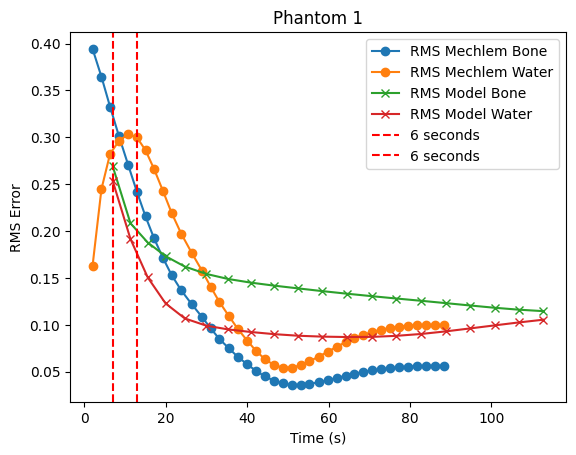

In [87]:
# calculate RMS for reconstructed images

rms_reconstructions_bone = []
rms_reconstructions_water = []
rms_models_bone = []
rms_models_water = []

for reconstruction, output_image, phantom in zip(reconstructions, output_images, phantoms): 

    rms_recon_bone = []
    rms_recon_water = []
    rms_model_bone = []
    rms_model_water = []

    phantom_bone = phantom[0].transpose()  # Get the ith bone
    phantom_water = phantom[1].transpose()  # Get the ith water

    # get first image from reconstruction
    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')

    for i in range(len(images[0, 0, 0, 0, :])):
        image_bone = images[:, :, :, 0, i]
        image_water = images[:, :, :, 1, i]
        rms_recon_bone.append(rms_error(image_bone, phantom_bone))
        rms_recon_water.append(rms_error(image_water, phantom_water))
    rms_reconstructions_bone.append(rms_recon_bone)
    rms_reconstructions_water.append(rms_recon_water)

    for image_bone, image_water in output_image:
        rms_model_bone.append(rms_error(image_bone, phantom_bone))
        rms_model_water.append(rms_error(image_water, phantom_water))
    rms_models_bone.append(rms_model_bone)
    rms_models_water.append(rms_model_water)
# Plot the RMS errors for the reconstructions and the models
# make subplot with 1 row and len(reconstructions) columns
# plot them against the times
n = 9
# plt.figure(figsize=(20, 10))
# for i in range(n):
#     time_model = np.array(times_images[i])
#     time_recon = np.array(times[i])
#     plt.subplot(1, n, i + 1)
#     plt.plot(time_recon, rms_reconstructions_bone[i], label='RMS Mechlem Bone', marker='o')
#     plt.plot(time_recon, rms_reconstructions_water[i], label='RMS Mechlem Water', marker='o')
#     plt.plot(time_model, rms_models_bone[i], label='RMS Model Bone', marker='x')
#     plt.plot(time_model, rms_models_water[i], label='RMS Model Water', marker='x')
#     plt.xlabel('Time (s)')
#     plt.ylabel('RMS Error')
#     plt.title(f'Phantom {i + 1}')
#     plt.legend()
# plt.tight_layout()
# plt.show()

i = 0
time_model = np.array(times_images[i])
time_recon = np.array(times[i])

plt.plot(time_recon, rms_reconstructions_bone[i], label='RMS Mechlem Bone', marker='o')
plt.plot(time_recon, rms_reconstructions_water[i], label='RMS Mechlem Water', marker='o')
plt.plot(time_model, rms_models_bone[i], label='RMS Model Bone', marker='x')
plt.plot(time_model, rms_models_water[i], label='RMS Model Water', marker='x')
# vertical bar at 6
plt.axvline(x=7, color='r', linestyle='--', label='6 seconds')
plt.axvline(x=12.9, color='r', linestyle='--', label='6 seconds')

plt.xlabel('Time (s)')
plt.ylabel('RMS Error')
plt.title(f'Phantom {i + 1}')
plt.legend()
plt.show()



In [97]:
# for each phantom we will check the speedup
# per phantom, get the average duration of each step and a standard deviation

# get all first times, so t = times[:][0]
first_times = [t[0] for t in times_images]

print("average first time:", np.mean(first_times), "+-", np.std(first_times), "seconds")

# We want to calculate the speedup for the first step and make a histogram of the speedup
# for the speedup we want to look at the output rms of the model and see for which time mechlem is lower than the model

speedups = []
interpolated_speedups = []

print(len(rms_reconstructions_bone))

for i in range(len(rms_reconstructions_bone)):
    rms_bone_model = rms_models_bone[i][0]
    rms_water_model = rms_models_water[i][0]

    for j in range(len(rms_reconstructions_bone[i])):
        
        if(rms_reconstructions_bone[i][j] < rms_bone_model):
            
            speedup = times[i][j] / first_times[i] 
            speedups.append(speedup)

            # also interpolate to see at what time the rms is the same
            slope = (rms_reconstructions_bone[i][j+1] - rms_reconstructions_bone[i][j]) / (times[i][j+1] - times[i][j])
            
            # see for what time the rms is the same
            if slope != 0:
                interpolated_time = (rms_bone_model - rms_reconstructions_bone[i][j]) / slope + times[i][j]
                interpolated_speedups.append(interpolated_time / first_times[i])
            else:
                interpolated_speedups.append(speedup)
            break


print("average speedup:", np.mean(speedups), "+-", np.std(speedups), "after", np.mean(first_times), "+-", np.std(first_times), "seconds")
print("interpolated speedups:", interpolated_speedups)
print("average interpolated speedup:", np.mean(interpolated_speedups), "+-", np.std(interpolated_speedups), "after", np.mean(first_times), "+-", np.std(first_times), "seconds")
print(speedups)

average first time: 9.347357761859893 +- 1.5048523200384376 seconds
20
average speedup: 1.6119690273535912 +- 0.3327647687994946 after 9.347357761859893 +- 1.5048523200384376 seconds
interpolated speedups: [1.5372497302099817, 1.478250657471559, 1.3228967941125576, 1.5904891783409643, 1.7086829991371115, 2.4707818832364628, 1.320879043449145, 1.1493685436247243, 1.6830929159154253, 1.3239914493031808, 1.5519855004526864, 1.43848623030468, 1.6520035620996254, 1.2151822688114997, 1.6920530519932997, 1.5422778294658155, 1.1405183043022253, 0.8991778140454925, 1.190062304067791, 0.9492814783410398]
average interpolated speedup: 1.4428355769342633 +- 0.3332045100786529 after 9.347357761859893 +- 1.5048523200384376 seconds
[1.8483086111906142, 1.5988229601683974, 1.526833824239783, 1.6222662035628952, 1.8657407050982648, 2.554958048316029, 1.6394246396673233, 1.2725802041881733, 1.9156772917384663, 1.6053813593318578, 1.8419109295031362, 1.455024708698463, 1.8646751185831827, 1.2549532431215

In [117]:
# now we want to display the output_images. one slider for the index and one slider for the iteration. also display the corresponding phantom

def display_output_image(index, itt):
    output_image = output_images[index][itt]  # Get the ith output image
    phantom = phantoms[index]  # Get the ith phantom
    phantom_bone = phantom[0].transpose()  # Get the bone phantom
    phantom_water = phantom[1].transpose()  # Get the water phantom

    bone_reconstructed = output_image[0]  # Maybe bone
    water_reconstructed = output_image[1]  # Maybe water

    reconstruction = reconstructions[index]  # Get the ith reconstruction
    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')
    bone_reconstructed_mechlem = images[:, :, :, 0, -1]  # Maybe bone
    water_reconstructed_mechlem = images[:, :, :, 1, -1]  # Maybe water

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 6, 1)
    plt.imshow(bone_reconstructed[:, :, objectSize // 2], cmap='gray')
    plt.title('Bone Reconstructed')
    plt.axis('off')
    plt.colorbar()
    plt.subplot(1, 6, 2)
    plt.imshow(water_reconstructed[:, :, objectSize // 2], cmap='gray')
    plt.title('Water Reconstructed')
    plt.axis('off')
    plt.colorbar()
    plt.subplot(1, 6, 3)
    plt.imshow(phantom_bone[:, :, objectSize // 2], cmap='gray')
    plt.title('Bone Original Phantom')
    plt.axis('off')
    plt.subplot(1, 6, 4)
    plt.imshow(phantom_water[:, :, objectSize // 2], cmap='gray')
    plt.title('Water Original Phantom')
    plt.axis('off')
    plt.subplot(1, 6, 5)
    plt.imshow(bone_reconstructed_mechlem[:, :, objectSize // 2], cmap='gray')
    plt.title('Bone Mechlem Reconstruction')
    plt.axis('off')
    plt.subplot(1, 6, 6)
    plt.imshow(water_reconstructed_mechlem[:, :, objectSize // 2], cmap='gray')
    plt.title('Water Mechlem Reconstruction')
    plt.axis('off')
    plt.show()

# Example usage
interact(display_output_image, index=IntSlider(min=0, max=len(output_images)-1, step=1, value=0), itt=IntSlider(min=0, max=len(output_images[0])-1, step=1, value=len(output_images[0])-1))

interactive(children=(IntSlider(value=0, description='index', max=4), IntSlider(value=6, description='itt', ma…

<function __main__.display_output_image(index, itt)>

In [92]:
object_to_save = {
    'reconstructions' : reconstructions,
    'ys' : ys,
    'times' : times,
    'phantoms' : phantoms,
    'output_images' : output_images,
    'times_images' : times_images,
    'rms_reconstructions_bone' : rms_reconstructions_bone,
    'rms_reconstructions_water' : rms_reconstructions_water,
    'rms_models_bone' : rms_models_bone,
    'rms_models_water' : rms_models_water,
}

# Save the object to a file
with open('phantom_results_3.pkl', 'wb') as f:
    pickle.dump(object_to_save, f)

5 5 5


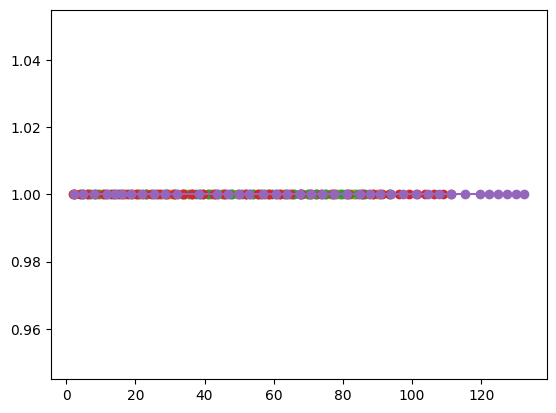

In [ ]:
print(len(reconstructions), len(times), len(ys))

for reconstruction, time, phantom in zip(reconstructions, times, phantoms):
    
    rms_error = np.zeros((nIter, 2))  # 2 for bone and water

    for i in range(nIter):
        bone_reconstructed, water_reconstructed, rms = get_best_image(reconstruction, phantom[0], phantom[1])
        rms_error[i, 0] = rms_error[i, 0] + rms_error(bone_reconstructed, phantom[0])
        rms_error[i, 1] = rms_error[i, 1] + rms_error(water_reconstructed, phantom[1])
    

    plt

In [10]:
n= 5
rms_1 = []
rms_2 = []

total_outputs = []
total_outputs_2 = []

best_reconstructed = []

for i in range(5):
    reconstruction = reconstructions[i]  # Get the first reconstruction
    y = ys[i]  # Get the first y
    # bone = bones[i].transpose()  # Get the first bone
    # water = waters[i].transpose()  # Get the first water

    # bone and water need 32x32x32 with value 0.05
    # bone = np.full((objectSize, objectSize, objectSize), 0.05)
    # water = np.full((objectSize, objectSize, objectSize),0.05)

    # get last reconstructed image 
    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')

    # get bone and water from first reconstruction
    bone = images[:, :, :, 0, 0]  # Maybe bone
    water = images[:, :, :, 1, 0]  # Maybe water

    outputs, outputs_2 = runModel(bone, water, y, 4)
    best_reconstructed.append(get_best_image(reconstruction, bone, water))

    # add array to total outputs, so total_outputs[i] results the output array
    total_outputs.append(outputs)
    total_outputs_2.append(outputs_2)
    rms = [rms_error(output[0], bone) for output in outputs]



C:\Users\luukf\AppData\Local\Temp\ipykernel_20068\2026440543.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  inputs_tensor = torch.tensor(input, dtype=torch.float32).unsqueeze(0)


In [13]:
best_reconstructed = []

for i in range(5):
    reconstruction = reconstructions[i]  # Get the first reconstruction
    y = ys[i]  # Get the first y
    bone = bones[i].transpose()  # Get the first bone
    water = waters[i].transpose()  # Get the first water

    best_reconstructed.append(get_best_image(reconstruction, bone, water))

print(best_reconstructed[4][2])  # Print the best RMS error for the first reconstruction

0.12964747691253228


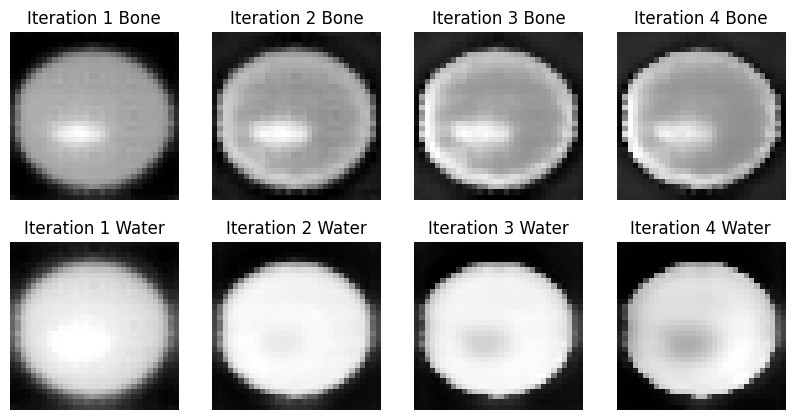

In [14]:
# we want to display all itearations of the model reconstruction
plt.figure(figsize=(10, 5))

for i in range(4):
    plt.subplot(2,4, i+1)
    plt.imshow(total_outputs[0][i][0][:, :, 16], cmap='gray')
    plt.title(f'Iteration {i+1} Bone')
    plt.axis('off')
    plt.subplot(2,4, i+5)
    plt.imshow(total_outputs[0][i][1][:, :, 16], cmap='gray')
    plt.title(f'Iteration {i+1} Water')
    plt.axis('off')

plt.show()

In [15]:
def display_output(index, itt, zValue):
    
    output_bone_2, output_water_2 = total_outputs_2[index][itt]

    rms_bone = rms_error(output_bone_2, bones[index].transpose())
    rms_water = rms_error(output_water_2, waters[index].transpose())
    print(f"RMS Error for Output Bone {index}: {rms_bone:.4f}")
    print(f"RMS Error for Output Water {index}: {rms_water:.4f}")
    print(f"RMS Error for Best Reconstructed Bone {index}: {best_reconstructed[index][2]:.4f}")
    print(f"RMS Error for Best Reconstructed Water {index}: {rms_error(best_reconstructed[index][1], waters[index].transpose()):.4f}")

    plt.figure(figsize=(4, 4))
    plt.subplot(3,2,1)
    plt.imshow(output_bone_2[:, :, zValue], cmap='gray')
    plt.title(f'Output Bone {index} z={zValue}')
    plt.axis('off')
    plt.colorbar()
    plt.subplot(3,2,2)
    plt.imshow(output_water_2[:, :, zValue], cmap='gray')
    plt.title(f'Output Water {index} z={zValue}')
    plt.axis('off')
    plt.colorbar()

    plt.subplot(3,2,3)
    plt.imshow(best_reconstructed[index][0][:, :, zValue], cmap='gray')
    plt.title(f'Best Bone {index} z={zValue}')
    plt.axis('off')
    plt.colorbar()

    plt.subplot(3,2,4)
    plt.imshow(best_reconstructed[index][1][:, :, zValue], cmap='gray')
    plt.title(f'Best Water {index} z={zValue}')
    plt.axis('off')
    plt.colorbar()

    plt.subplot(3,2,5)
    plt.imshow(bones[index].transpose()[:, :, zValue], cmap='gray')
    plt.title(f'Original Bone {index} z={zValue}')
    plt.axis('off')
    plt.colorbar()

    plt.subplot(3,2,6)
    plt.imshow(waters[index].transpose()[:, :, zValue], cmap='gray')
    plt.title(f'Original Water {index} z={zValue}')
    plt.axis('off')
    plt.colorbar()

    
    plt.tight_layout()
    plt.show()

    # for i in range(4):
    #     output_bone, output_water = total_outputs[0][i]
    #     output_bone_2, output_water_2 = total_outputs_2[index][i]
        
    #     plt.subplot(3, 4, i + 1)
    #     plt.imshow(output_bone_2[:, :, zValue], cmap='gray')
    #     plt.title(f'Output {i+1} Bone')
    #     plt.axis('off')

    #     plt.subplot(3, 4, i + 5)
    #     plt.imshow(output_water_2[:, :, zValue], cmap='gray')
    #     plt.title(f'Output {i+1} water')
    #     plt.axis('off')

    #     plt.subplot(3, 4, i + 9)
    #     plt.imshow(best_reconstructed[index][0][:, :, zValue], cmap='gray')
    #     plt.title(f'Best Bone {index} z={zValue}')
    #     plt.axis('off')
        
    #     plt.subplot()

# Example usage
interact(display_output, index=(0, len(total_outputs)-1), zValue=IntSlider(min=0, max=31, step=1, value=16), itt = IntSlider(min=0, max =4, step=1))  # Assuming the z-dimension is 32

interactive(children=(IntSlider(value=2, description='index', max=4), IntSlider(value=0, description='itt', ma…

<function __main__.display_output(index, itt, zValue)>

## Run Mechlem and network

In [ ]:
# generate phantom 



## compare time 

- check error against time for both


In [ ]:
# run mechlem, keep track of time between iterations and rms error

# run model, keep track of time between iterations and rms error

# plot the results

In [13]:
# we want to load from "validation" folder all data_{i}.pkl files
# alle 
import os, pickle
phantoms = []
ys = []
reconstructions = []
times = []

for i in range(len(os.listdir('validation'))):
    if f'data_{i}.pkl' in os.listdir('validation'):
        with open(f'validation/data_{i}.pkl', 'rb') as f:
            data = pickle.load(f)
            phantoms.extend([d['phantom'] for d in data])
            ys.extend([d['y'] for d in data])
            reconstructions.extend([d['itt_reconstruction'] for d in data])
            times.extend([d['time_array'] for d in data])

# print length of phantoms, ys, reconstructions, times
print(f"Loaded {len(phantoms)} phantoms, {len(ys)}")

Loaded 72 phantoms, 72


In [33]:
# load model output from "validation" folder, model_outputs.pkl
with open('validation/model_outputs.pkl', 'rb') as f:
    model_outputs = pickle.load(f)
    model_images = model_outputs['outputs_all']
    model_times = model_outputs['times_all']

print(f"Loaded {len(model_images)} model images, {len(model_times)} model times")

# remove first 4 from both
model_images = model_images[4:]
model_times = model_times[4:]

# now 

Loaded 26 model images, 26 model times


In [34]:
def rms_error(image1, image2):
    if image1.shape != image2.shape:
        raise ValueError("Images must have the same dimensions")

    # Calculate the squared differences
    squared_diff = (image1 - image2) ** 2

    # Calculate the mean of the squared differences
    mean_squared_diff = np.mean(squared_diff)

    # Return the square root of the mean squared difference
    return np.sqrt(mean_squared_diff)

In [35]:
import numpy as np

objectSize = 32  # Assuming objectSize is defined as 32

rms_bone_itt = []
rms_water_itt = []

rms_bone_model = []
rms_water_model = []

for i in range(len(model_images)):
    bone = phantoms[i][0]  # Get the ith bone
    water = phantoms[i][1]  # Get the ith water

    reconstruction = reconstructions[i]  # Get the ith reconstruction
    _, nMats, nIterates = reconstruction.shape
    images = reconstruction.reshape((objectSize, objectSize, objectSize, nMats, nIterates), order = 'F')

    phantom_rms_bone = []
    phantom_rms_water = []

    for j in range(nIterates):
        image_bone = images[:, :, :, 0, j]
        image_water = images[:, :, :, 1, j]
        phantom_rms_bone.append(rms_error(image_bone, bone))
        phantom_rms_water.append(rms_error(image_water, water))
    
    rms_bone_itt.append(phantom_rms_bone)
    rms_water_itt.append(phantom_rms_water)

    model_rms_bone = []
    model_rms_water = []

    for model_image in model_images[i]:
        model_bone, model_water = model_image
        model_rms_bone.append(rms_error(model_bone, bone))
        model_rms_water.append(rms_error(model_water, water))
    
    rms_bone_model.append(model_rms_bone)
    rms_water_model.append(model_rms_water)


print(f"number of length of rms_bone_itt: {len(rms_bone_itt)}, {len(rms_bone_itt[0])}")

number of length of rms_bone_itt: 22, 40


In [36]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# slider as index, plot water, bone rms for model and mechlem against time

def plot_rms(index):
    time_itt = times[index]
    time_model = model_times[index]

    plt.figure(figsize=(12, 6))
    plt.plot(time_itt, rms_bone_itt[index], label='RMS Mechlem Bone', marker='o')
    plt.plot(time_itt, rms_water_itt[index], label='RMS Mechlem Water', marker='o')
    plt.plot(time_model, rms_bone_model[index], label='RMS Model Bone', marker='x')
    plt.plot(time_model, rms_water_model[index], label='RMS Model Water', marker='x')
    
    plt.xlabel('Time (s)')
    plt.ylabel('RMS Error')
    plt.title(f'Phantom {index + 1} RMS Errors')
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
interact(plot_rms, index=IntSlider(min=0, max=len(rms_bone_itt)-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='index', max=21), Output()), _dom_classes=('widget-intera…

<function __main__.plot_rms(index)>

In [38]:
# i as index, display model image[0] for bone and phantom for bone

def display_model_image(index, zValue, img_indx):
    model_image = model_images[index][img_indx][0]  # Get the first model image for bone
    phantom_bone = phantoms[index][0]  # Get the ith bone phantom

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(model_image[zValue, :, :], cmap='gray')
    plt.title(f'Model Bone Image {index + 1} at z={zValue}')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(phantom_bone[zValue, :, :], cmap='gray')
    plt.title(f'Phantom Bone {index + 1} at z={zValue}')
    plt.axis('off')
    
    plt.show()

# Example usage
interact(display_model_image, index=IntSlider(min=0, max=len(model_images)-1, step=1, value=0), zValue=IntSlider(min=0, max=31, step=1, value=16), img_indx = IntSlider(min = 0, max = 5, value = 0))  # Assuming the z-dimension is 32

interactive(children=(IntSlider(value=0, description='index', max=21), IntSlider(value=16, description='zValue…

<function __main__.display_model_image(index, zValue, img_indx)>